In [56]:
from cd.algs.kernels.temporal_kernel import *
from cd.algs.bases.temporal_basis import *
import matplotlib.pyplot as plt
from cd.data.datasets import load_experiment, trim_transient
from cd.algs.bilinear_trajectory_encoder import *
from cd.utils.plotting import plot_channels
from cd.utils.windows import strided_window_view

## Temporal kernels

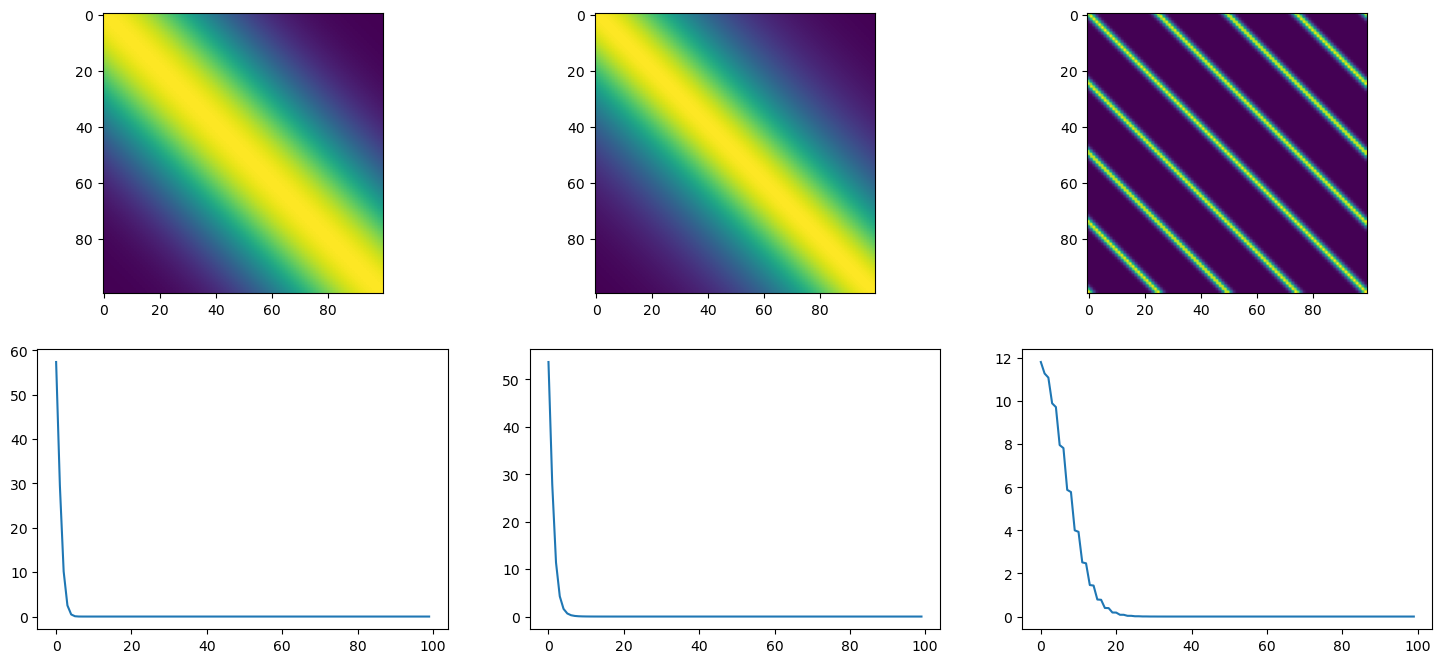

In [2]:
t = np.linspace(0, 1, 100)
fig, ax = plt.subplots(2, 3, figsize=(18, 8))

l = 0.29
K_rbf = RBFKernel(n_steps=100, length_scale=l)(t)
K_matern = MaternKernel(n_steps=100, length_scale=l)(t)
K_periodic = PeriodicKernel(period=0.25, n_steps=100, length_scale=l)(t)

ax[0,0].imshow(K_rbf)
ax[0,1].imshow(K_matern)
ax[0,2].imshow(K_periodic)

ax[1,0].plot(np.linalg.eigvalsh(K_rbf)[::-1])
ax[1,1].plot(np.linalg.eigvalsh(K_matern)[::-1])
ax[1,2].plot(np.linalg.eigvalsh(K_periodic)[::-1])

In [3]:
def var_explained(K):
    eigvals = np.linalg.eigvalsh(K)[::-1]  # big to small
    var_explained = np.cumsum(eigvals) / np.sum(eigvals)
    return np.searchsorted(var_explained, 0.95), np.searchsorted(var_explained, 0.99)

var_explained(K_rbf), var_explained(K_matern), var_explained(K_periodic)

((np.int64(2), np.int64(3)),
 (np.int64(3), np.int64(5)),
 (np.int64(13), np.int64(18)))

## Envs

In [32]:
x_tr, x_te, y_true, _ = load_experiment('humanoid', trim=True, normalize=False, win=30)

In [33]:
x_tr = strided_window_view(x_tr, window=x_te.shape[1], stride=100).reshape(-1, x_te.shape[1], x_tr.shape[-1])

In [34]:
x_tr.shape

(3000, 30, 45)

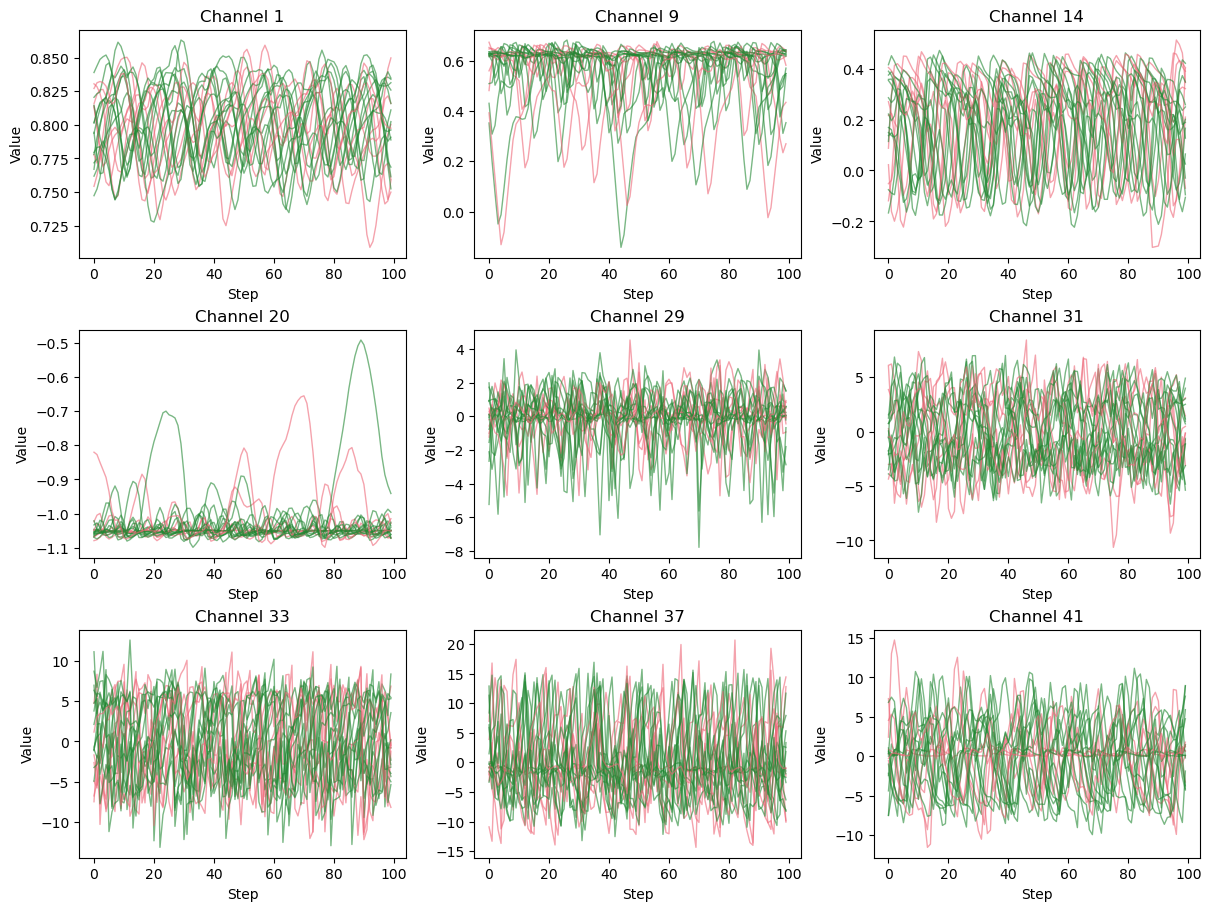

In [5]:
plot_channels(x_te, y_true);

In [163]:
from cd.utils.signals import estimate_period_acf

In [164]:
period = estimate_period_acf(x_tr) / x_te.shape[1]
period

0.17

In [165]:
1 / 100

0.01

RBF: 0.5528377484941873
Matern: 0.550960628759818


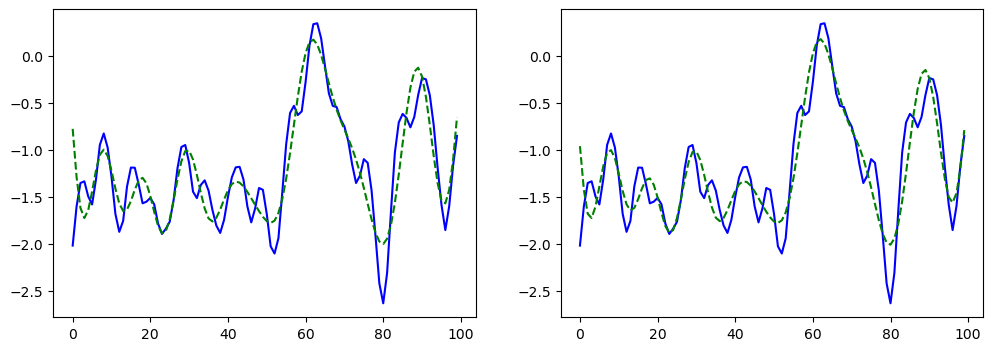

In [170]:
x = x_tr[0]

l = 0.01
k1 = RBFKernel(n_steps=x_te.shape[1], ridge=1e-6, rank=20, length_scale=l)
k2 = MaternKernel(n_steps=x_te.shape[1], ridge=1e-6, rank=20, length_scale=l, order=0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

z = k1.transform(x)
xhat = k1.inverse_transform(z)
print(f'RBF: {np.linalg.norm(x-xhat)/np.linalg.norm(x)}')
ax[0].plot(x[:,:1], 'b-')
ax[0].plot(xhat[:,:1], 'g--')

z = k2.transform(x)
xhat = k2.inverse_transform(z)
print(f'Matern: {np.linalg.norm(x-xhat)/np.linalg.norm(x)}')
ax[1].plot(x[:,:1], 'b-')
ax[1].plot(xhat[:,:1], 'g--')

In [151]:
def _make_product_kernel(n_steps, ridge, rank, ls_periodic, ls_rbf, period):
    """Periodic * RBF product kernel."""
    t = np.linspace(0, 1, n_steps)
    K_per = PeriodicKernel(n_steps=n_steps, length_scale=ls_periodic, period=period)(t)
    K_rbf = RBFKernel(n_steps=n_steps, length_scale=ls_rbf)(t)
    K_prod = K_per * K_rbf

    class _Stub:
        pass
    stub = _Stub()
    T = n_steps
    eigvals, eigvecs = np.linalg.eigh(K_prod)
    idx = np.argsort(eigvals)[::-1][:rank]
    lam = eigvals[idx]
    stub.U_r_ = eigvecs[:, idx]
    stub.H_ = np.diag(lam / (lam + ridge)) @ stub.U_r_.T
    stub.transform = lambda X: stub.H_ @ X
    stub.inverse_transform = lambda E: stub.U_r_ @ E
    return stub


def gridsearch_temporal_kernels(X, ranks=None, length_scales=None, ridge=1e-6):
    """For each kernel type and rank, find the length_scale(s) that minimize
    relative reconstruction error.

    Returns dict mapping kernel name to list of (rank, best_error, best_params).
    """
    N, T, D = X.shape
    if ranks is None:
        ranks = [r for r in [10, 15, 20, 25, 30] if r < T]
    if length_scales is None:
        length_scales = np.logspace(-2, 0, 20).tolist()

    period = estimate_period_acf(X) / T

    results = {name: [] for name in ["RBF", "Matern", "Periodic", "Periodic*RBF"]}

    for rank in ranks:
        # Single length_scale kernels
        for name in ["RBF", "Matern", "Periodic"]:
            best_err, best_ls = np.inf, None
            for ls in length_scales:
                if name == "RBF":
                    k = RBFKernel(n_steps=T, ridge=ridge, rank=rank, length_scale=ls)
                elif name == "Matern":
                    k = MaternKernel(n_steps=T, ridge=ridge, rank=rank, length_scale=ls)
                else:
                    k = PeriodicKernel(n_steps=T, ridge=ridge, rank=rank, length_scale=ls, period=period)
                x_hat = k.inverse_transform(k.transform(X))
                err = np.linalg.norm(X - x_hat) / np.linalg.norm(X)
                if err < best_err:
                    best_err, best_ls = err, ls
            results[name].append((rank, best_err, {"ls": best_ls}))

        # Product kernel: grid search over both length_scales
        best_err, best_ls_per, best_ls_rbf = np.inf, None, None
        for ls_per in length_scales:
            for ls_rbf in length_scales:
                k = _make_product_kernel(T, ridge, rank, ls_per, ls_rbf, period)
                x_hat = k.inverse_transform(k.transform(X))
                err = np.linalg.norm(X - x_hat) / np.linalg.norm(X)
                if err < best_err:
                    best_err, best_ls_per, best_ls_rbf = err, ls_per, ls_rbf
        results["Periodic*RBF"].append((rank, best_err, {"ls_per": best_ls_per, "ls_rbf": best_ls_rbf}))

    for name, rank_results in results.items():
        label = f"{name} (period={period:.2f})" if "Periodic" in name else name
        print(f"\n{label}:")
        for rank, err, params in rank_results:
            p = "  ".join(f"{k}={v:.4f}" for k, v in params.items())
            print(f"  rank={rank:3d}  error={err:.4f}  {p}")

    return results

results = gridsearch_temporal_kernels(x_tr)


RBF:
  rank= 10  error=0.7823  ls=0.2976
  rank= 15  error=0.5631  ls=0.0546
  rank= 20  error=0.5123  ls=0.0886
  rank= 25  error=0.4144  ls=0.0264
  rank= 30  error=0.3578  ls=0.0264

Matern:
  rank= 10  error=0.7901  ls=1.0000
  rank= 15  error=0.5634  ls=0.0695
  rank= 20  error=0.5132  ls=0.0886
  rank= 25  error=0.4144  ls=0.0264
  rank= 30  error=0.3577  ls=0.0428

Periodic (period=0.17):
  rank= 10  error=0.8100  ls=1.0000
  rank= 15  error=0.8065  ls=1.0000
  rank= 20  error=0.8042  ls=0.6158
  rank= 25  error=0.7992  ls=0.0886
  rank= 30  error=0.7704  ls=0.0546

Periodic*RBF (period=0.17):
  rank= 10  error=0.6461  ls_per=1.0000  ls_rbf=0.1833
  rank= 15  error=0.5421  ls_per=1.0000  ls_rbf=0.2336
  rank= 20  error=0.4673  ls_per=1.0000  ls_rbf=0.1833
  rank= 25  error=0.4079  ls_per=1.0000  ls_rbf=0.1438
  rank= 30  error=0.3576  ls_per=1.0000  ls_rbf=0.1129


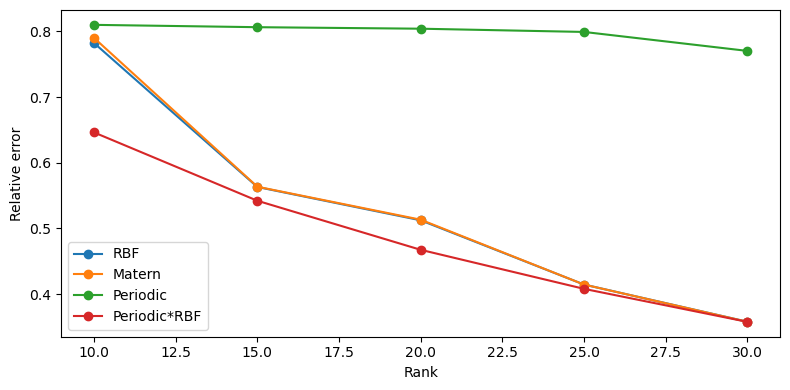

In [152]:
fig, ax1 = plt.subplots(figsize=(8, 4))

for name, rank_results in results.items():
    ranks, errors, _ = zip(*rank_results)
    ax1.plot(ranks, errors, 'o-', label=name)

ax1.set_xlabel('Rank')
ax1.set_ylabel('Relative error')
ax1.legend()
fig.tight_layout()

In [ ]:
channel_stats(x_tr_nys)